# Sentinel-1 Orbit Direction Analysis

Analyse how many months per tile have **ascending-only**, **descending-only**, or **both** orbit passes.
This matters because ascending and descending orbits have different viewing geometries and backscatter characteristics.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

DATA = Path('../data/concept_data/sentinel-1')

## Parse all S1 files into a DataFrame

In [2]:
rows = []
for split in ['train', 'test']:
    for tile_dir in sorted((DATA / split).iterdir()):
        tid = tile_dir.name.replace('__s1_rtc', '')
        for f in tile_dir.glob('*.tif'):
            m = re.search(r'_(\d{4})_(\d{1,2})_(ascending|descending)', f.stem)
            if m:
                rows.append({
                    'split': split,
                    'tile_id': tid,
                    'year': int(m.group(1)),
                    'month': int(m.group(2)),
                    'orbit': m.group(3),
                    'file': f.name,
                })

df = pd.DataFrame(rows)
print(f'Total S1 files: {len(df)}')
print(f'Tiles: {df["tile_id"].nunique()}  (train={df[df.split=="train"]["tile_id"].nunique()}, test={df[df.split=="test"]["tile_id"].nunique()})')
df.head()

Total S1 files: 2445
Tiles: 21  (train=16, test=5)


,split,tile_id,year,month,orbit,file
0,train,18NWG_6_6,2021,2,descending,18NWG_6_6__s1_rtc_2021_2_descending.tif
1,train,18NWG_6_6,2025,3,descending,18NWG_6_6__s1_rtc_2025_3_descending.tif
2,train,18NWG_6_6,2020,1,descending,18NWG_6_6__s1_rtc_2020_1_descending.tif
3,train,18NWG_6_6,2020,12,ascending,18NWG_6_6__s1_rtc_2020_12_ascending.tif
4,train,18NWG_6_6,2024,8,descending,18NWG_6_6__s1_rtc_2024_8_descending.tif


## Monthly orbit availability per tile

For each tile+year+month, classify as: **both**, **ascending-only**, or **descending-only**.

In [3]:
# Group by tile, year, month → set of orbits
monthly = df.groupby(['split', 'tile_id', 'year', 'month'])['orbit'].apply(set).reset_index()
monthly['orbit_type'] = monthly['orbit'].apply(
    lambda s: 'both' if len(s) == 2 else ('ascending-only' if 'ascending' in s else 'descending-only')
)

# Summary per tile
tile_summary = monthly.groupby(['split', 'tile_id', 'orbit_type']).size().unstack(fill_value=0)
tile_summary['total_months'] = tile_summary.sum(axis=1)
tile_summary = tile_summary.sort_index()
print(tile_summary.to_string())
print(f'\nTotal month-slots: {len(monthly)}')

orbit_type       ascending-only  both  descending-only  total_months
split tile_id                                                       
test  18NVJ_1_6               0    29               43            72
      18NYH_2_1               0    32               38            70
      33NTE_5_1              71     1                0            72
      47QMA_6_2               0    71                1            72
      48PWA_0_6               0    72                0            72
train 18NWG_6_6               0    32               38            70
      18NWH_1_4               0    32               38            70
      18NWJ_8_9               0    32               38            70
      18NWM_9_4               0     0               70            70
      18NXH_6_8               0    32               38            70
      18NXJ_7_6               0    32               38            70
      18NYH_9_9               0    32               38            70
      19NBD_4_4              14   

## Overall orbit type distribution (across all tile-months)

Across all tiles and months:
orbit_type
both               980
descending-only    397
ascending-only      88
Name: count, dtype: int64

Total: 1465


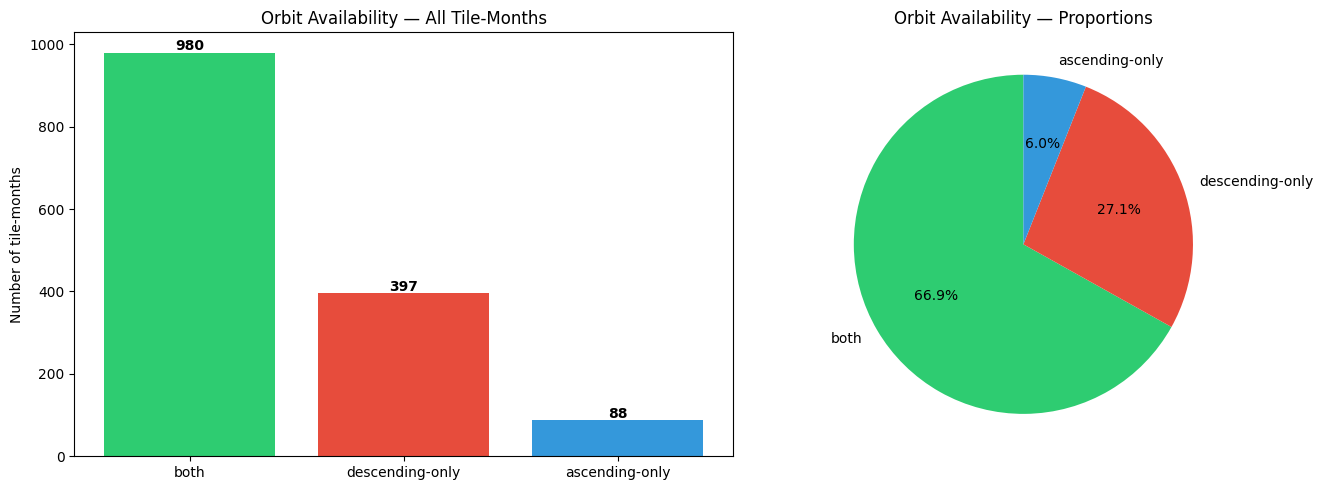

In [4]:
counts = monthly['orbit_type'].value_counts()
print('Across all tiles and months:')
print(counts)
print(f'\nTotal: {counts.sum()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — overall counts
colors = {'both': '#2ecc71', 'ascending-only': '#3498db', 'descending-only': '#e74c3c'}
bars = axes[0].bar(counts.index, counts.values, color=[colors[c] for c in counts.index])
axes[0].set_title('Orbit Availability — All Tile-Months')
axes[0].set_ylabel('Number of tile-months')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=[colors[c] for c in counts.index],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Orbit Availability — Proportions')

plt.tight_layout()
plt.show()

## Per-tile stacked bar chart

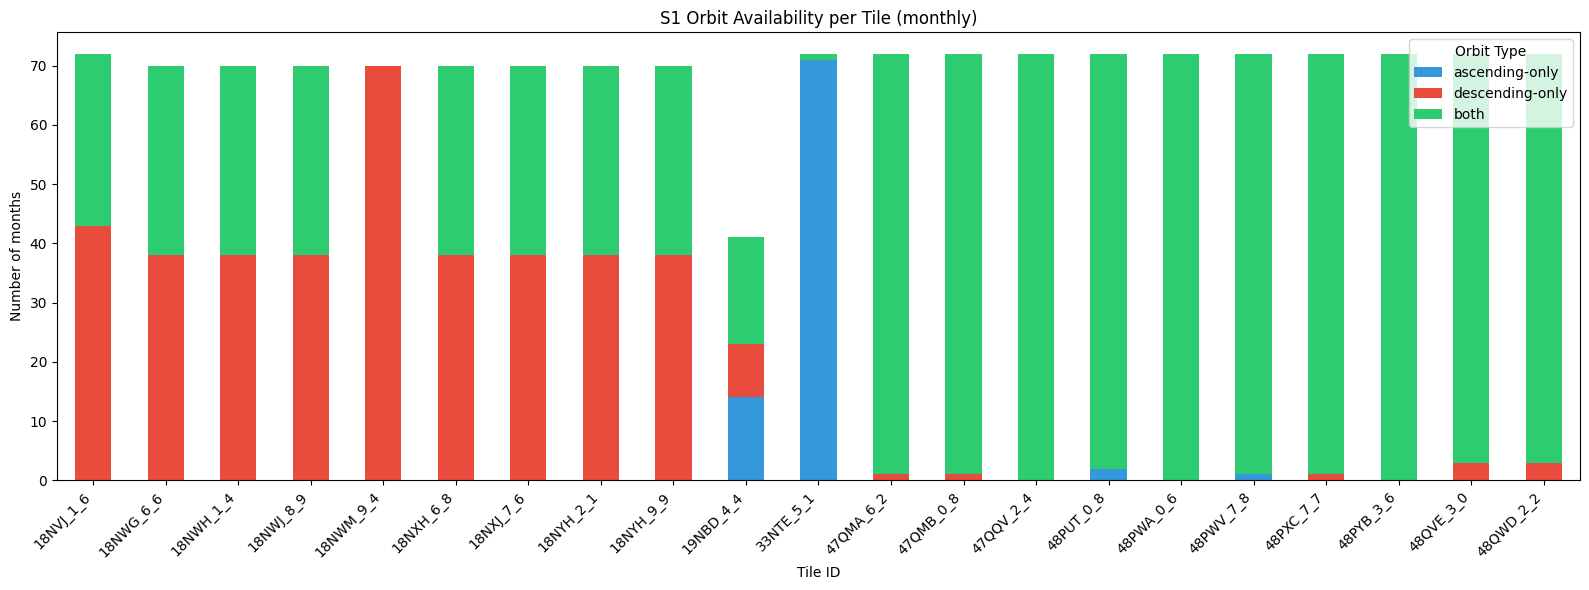

In [5]:
# Stacked bar per tile
pivot = monthly.groupby(['tile_id', 'orbit_type']).size().unstack(fill_value=0)
for col in ['ascending-only', 'descending-only', 'both']:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[['ascending-only', 'descending-only', 'both']]

fig, ax = plt.subplots(figsize=(16, 6))
pivot.plot(kind='bar', stacked=True, ax=ax, color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_title('S1 Orbit Availability per Tile (monthly)')
ax.set_ylabel('Number of months')
ax.set_xlabel('Tile ID')
ax.legend(title='Orbit Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Year-by-year breakdown per tile (heatmap)

/var/folders/x5/_0qtdzg57193jjdlt702pxq80000gp/T/ipykernel_14055/1278069007.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dom = monthly.groupby(['tile_id', 'year']).apply(dominant_orbit).unstack(fill_value='none')
/var/folders/x5/_0qtdzg57193jjdlt702pxq80000gp/T/ipykernel_14055/1278069007.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dom_num = dom.replace(orbit_map)


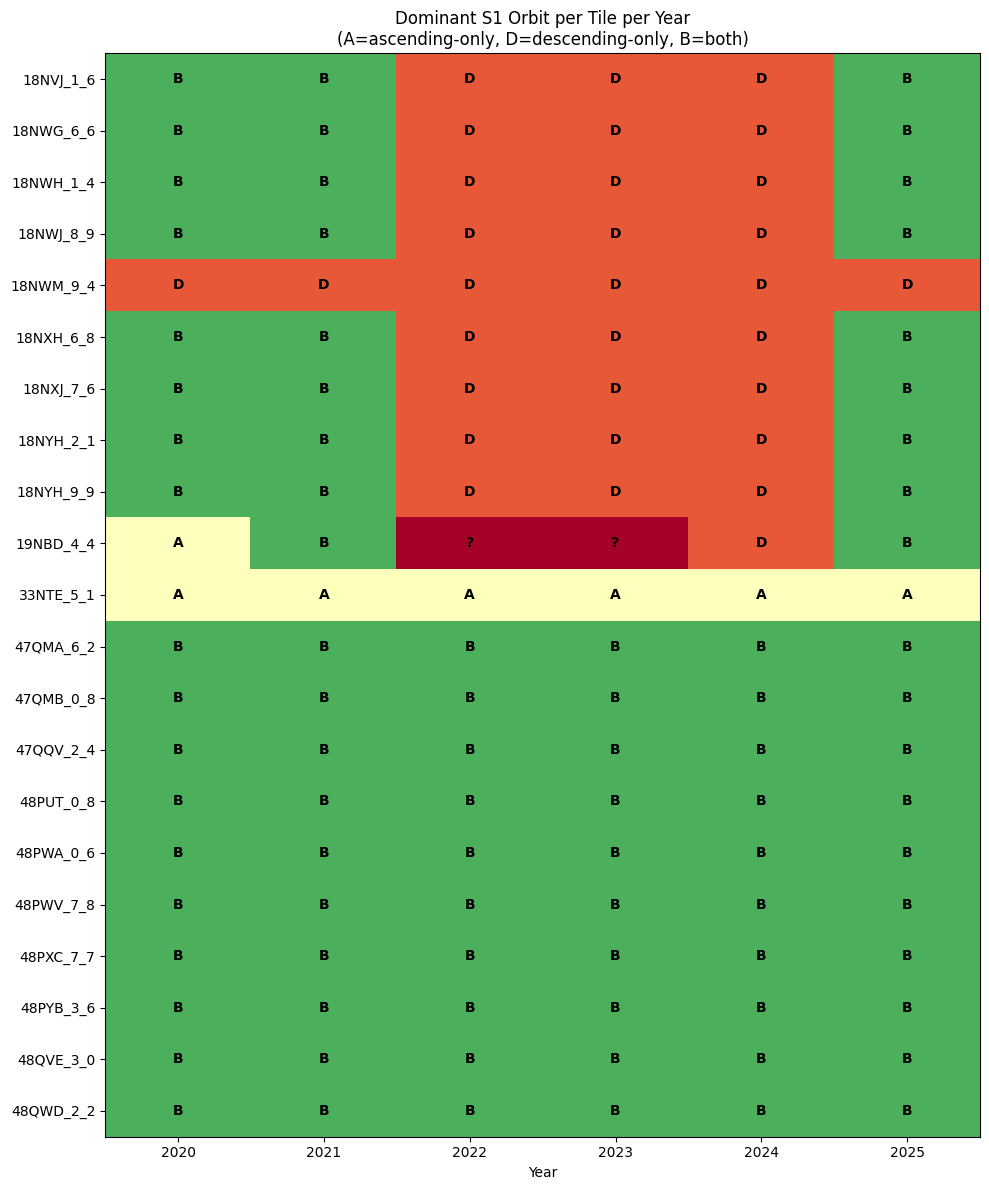

In [6]:
# For each tile+year, compute dominant orbit type
yearly = monthly.groupby(['tile_id', 'year', 'orbit_type']).size().reset_index(name='count')
yearly_pivot = yearly.pivot_table(index='tile_id', columns=['year', 'orbit_type'], values='count', fill_value=0)

# Simpler view: dominant type per tile+year
def dominant_orbit(group):
    counts = group['orbit_type'].value_counts()
    if len(counts) == 1:
        return counts.index[0]
    # If both exists and is majority
    if 'both' in counts.index and counts['both'] >= counts.sum() * 0.5:
        return 'both'
    return counts.index[0]

dom = monthly.groupby(['tile_id', 'year']).apply(dominant_orbit).unstack(fill_value='none')

# Encode as numeric for heatmap: both=2, asc-only=1, desc-only=0
orbit_map = {'both': 2, 'ascending-only': 1, 'descending-only': 0, 'none': -1}
dom_num = dom.replace(orbit_map)

fig, ax = plt.subplots(figsize=(10, 12))
im = ax.imshow(dom_num.values, aspect='auto', cmap=plt.cm.RdYlGn, vmin=-0.5, vmax=2.5)

ax.set_xticks(range(len(dom_num.columns)))
ax.set_xticklabels(dom_num.columns)
ax.set_yticks(range(len(dom_num.index)))
ax.set_yticklabels(dom_num.index)

# Annotate cells with text
for i in range(len(dom_num.index)):
    for j in range(len(dom_num.columns)):
        label = dom.iloc[i, j] if dom.iloc[i, j] != 'none' else '—'
        short = {'both': 'B', 'ascending-only': 'A', 'descending-only': 'D', 'none': '—'}
        ax.text(j, i, short.get(label, '?'), ha='center', va='center', fontsize=10, fontweight='bold')

ax.set_title('Dominant S1 Orbit per Tile per Year\n(A=ascending-only, D=descending-only, B=both)')
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

## Ascending vs Descending Agreement

For tile-months with **both** orbits, compare pixel values between ascending and descending.
Metrics: correlation, mean absolute difference, and spatial pattern similarity.

In [8]:
import rasterio
from scipy.stats import pearsonr

S1_DATA = Path('../data/concept_data/sentinel-1')

# Find all tile-month pairs that have both orbits
both_pairs = monthly[monthly['orbit_type'] == 'both'].copy()

# Sample up to 3 pairs per tile to keep it manageable
sampled = both_pairs.groupby('tile_id').apply(lambda g: g.sample(min(3, len(g)), random_state=42), include_groups=False).reset_index(level=0)

results = []
for _, row in sampled.iterrows():
    split_val, tid, year, month = df[df.tile_id == row['tile_id']]['split'].iloc[0], row['tile_id'], row['year'], row['month']
    tile_dir = S1_DATA / split_val / f'{tid}__s1_rtc'
    
    asc_files = list(tile_dir.glob(f'*_{year}_{month}_ascending.tif'))
    desc_files = list(tile_dir.glob(f'*_{year}_{month}_descending.tif'))
    
    if not asc_files or not desc_files:
        continue
    
    with rasterio.open(asc_files[0]) as src:
        asc = src.read().astype(np.float32)
    with rasterio.open(desc_files[0]) as src:
        desc = src.read().astype(np.float32)
    
    # Crop to common shape
    min_h = min(asc.shape[1], desc.shape[1])
    min_w = min(asc.shape[2], desc.shape[2])
    asc = asc[:, :min_h, :min_w]
    desc = desc[:, :min_h, :min_w]
    
    for b in range(min(asc.shape[0], desc.shape[0])):
        a_band = asc[b]
        d_band = desc[b]
        
        valid = np.isfinite(a_band) & np.isfinite(d_band) & (a_band != 0) & (d_band != 0)
        if valid.sum() < 100:
            continue
        
        a_v = a_band[valid]
        d_v = d_band[valid]
        
        corr, _ = pearsonr(a_v, d_v)
        mae = np.mean(np.abs(a_v - d_v))
        rel_mae = mae / (np.mean(np.abs(a_v)) + 1e-8)
        mean_diff_pct = abs(a_v.mean() - d_v.mean()) / (a_v.mean() + 1e-8) * 100
        
        results.append({
            'tile_id': tid, 'year': year, 'month': month, 'band': b + 1,
            'valid_px': int(valid.sum()),
            'asc_mean': a_v.mean(), 'desc_mean': d_v.mean(),
            'correlation': corr, 'MAE': mae, 'rel_MAE': rel_mae,
            'mean_diff_%': mean_diff_pct,
        })

res_df = pd.DataFrame(results)
print(f'Compared {len(res_df)} band-pairs across {res_df["tile_id"].nunique()} tiles\n')
print(res_df.to_string(index=False, float_format='%.4f'))

Compared 56 band-pairs across 20 tiles

  tile_id  year  month  band  valid_px  asc_mean  desc_mean  correlation    MAE  rel_MAE  mean_diff_%
18NVJ_1_6  2025     10     1     67451    0.2240     0.2333       0.0191 0.1596   0.7125       4.1251
18NVJ_1_6  2021      6     1     66705    0.2609     0.2788       0.0075 0.1877   0.7194       6.8904
18NVJ_1_6  2021      1     1     67015    0.2415     0.2618       0.0034 0.1746   0.7228       8.3897
18NWG_6_6  2025     10     1    111890    0.1821     0.2067       0.2477 0.0917   0.5036      13.5286
18NWG_6_6  2021      4     1    111890    0.2388     0.2758       0.0018 0.1235   0.5170      15.4838
18NWG_6_6  2025      5     1    111890    0.2320     0.2389       0.1201 0.1091   0.4705       2.9847
18NWH_1_4  2025     10     1     27779    0.2319     0.2240       0.0306 0.1408   0.6072       3.3940
18NWH_1_4  2021      4     1     27126    0.2343     0.2724       0.0503 0.1600   0.6829      16.2355
18NWH_1_4  2025      5     1     27052    

=== Summary across all compared pairs ===

       correlation     MAE  rel_MAE  mean_diff_%
count      56.0000 56.0000  56.0000      56.0000
mean        0.0905  0.1121   0.5356       9.1714
std         0.1190  0.0289   0.0780       6.5055
min        -0.1135  0.0565   0.4361       0.4896
25%         0.0166  0.0941   0.4771       3.7018
50%         0.0532  0.1094   0.5129       8.4653
75%         0.1191  0.1237   0.5626      13.5703
max         0.4959  0.1877   0.7228      24.9599


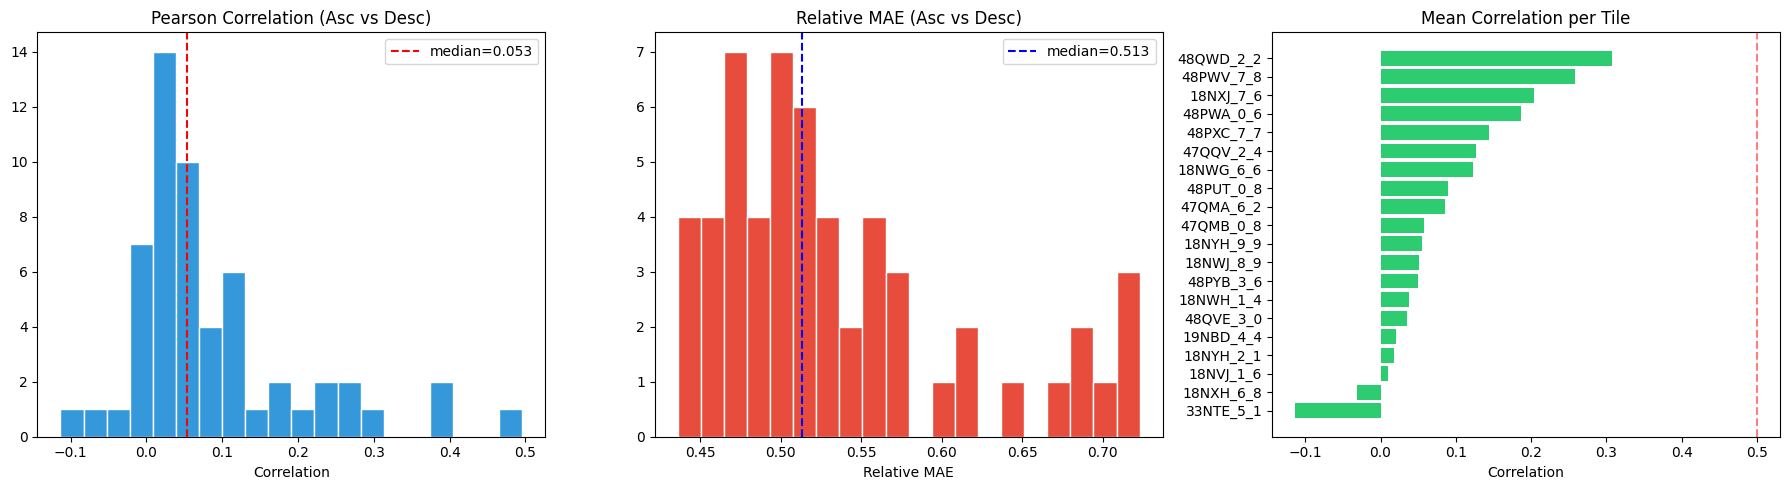

In [9]:
# Summary statistics
print('=== Summary across all compared pairs ===\n')
print(res_df[['correlation', 'MAE', 'rel_MAE', 'mean_diff_%']].describe().to_string(float_format='%.4f'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Correlation distribution
axes[0].hist(res_df['correlation'], bins=20, color='#3498db', edgecolor='white')
axes[0].axvline(res_df['correlation'].median(), color='red', linestyle='--', label=f'median={res_df["correlation"].median():.3f}')
axes[0].set_title('Pearson Correlation (Asc vs Desc)')
axes[0].set_xlabel('Correlation')
axes[0].legend()

# 2. Relative MAE distribution
axes[1].hist(res_df['rel_MAE'], bins=20, color='#e74c3c', edgecolor='white')
axes[1].axvline(res_df['rel_MAE'].median(), color='blue', linestyle='--', label=f'median={res_df["rel_MAE"].median():.3f}')
axes[1].set_title('Relative MAE (Asc vs Desc)')
axes[1].set_xlabel('Relative MAE')
axes[1].legend()

# 3. Mean diff % per tile
tile_corr = res_df.groupby('tile_id')['correlation'].mean().sort_values()
axes[2].barh(tile_corr.index, tile_corr.values, color='#2ecc71')
axes[2].set_title('Mean Correlation per Tile')
axes[2].set_xlabel('Correlation')
axes[2].axvline(0.5, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

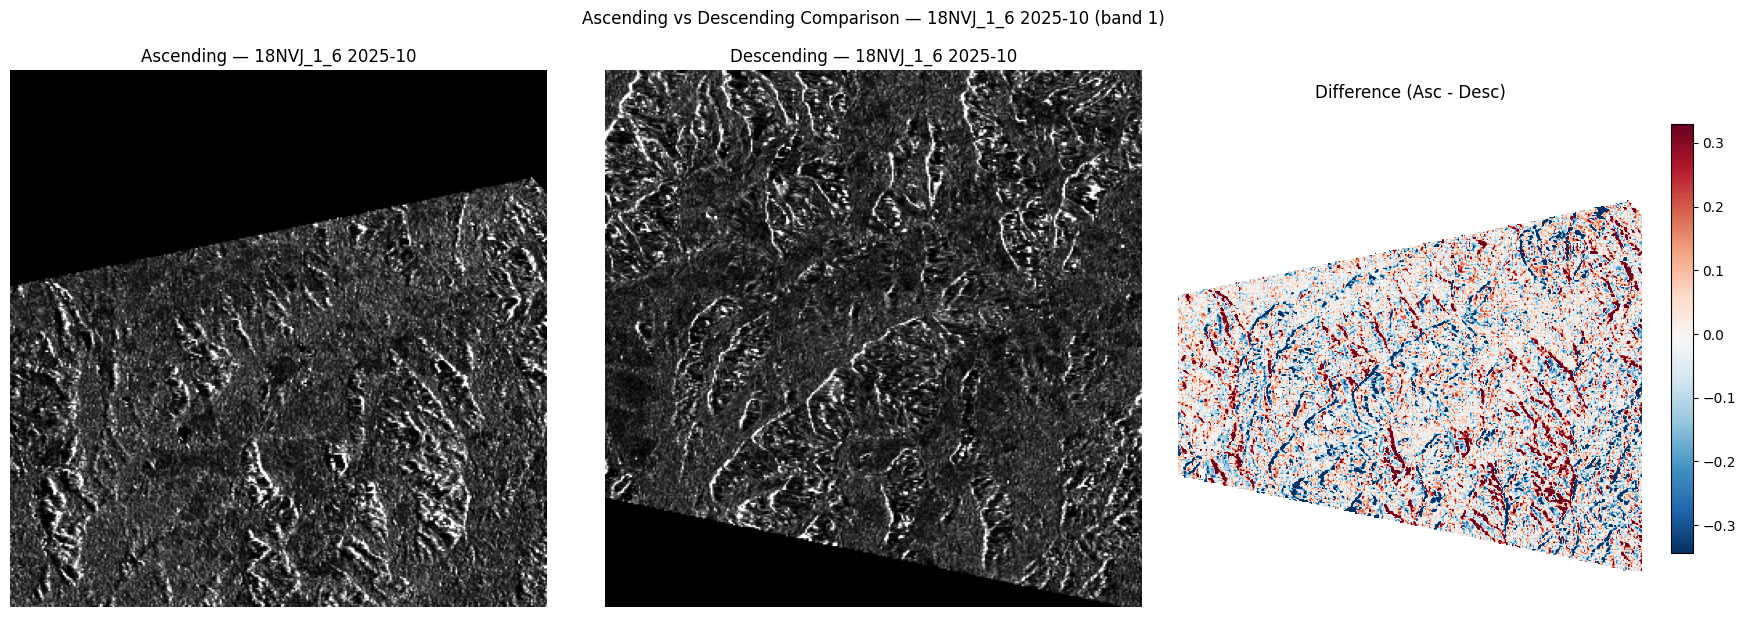

Correlation for this pair: 0.0191


In [10]:
# Visual comparison: pick one tile-month and show asc vs desc side-by-side
sample = res_df.iloc[0]
tid, yr, mo = sample['tile_id'], int(sample['year']), int(sample['month'])
split_val = df[df.tile_id == tid]['split'].iloc[0]
tile_dir = S1_DATA / split_val / f'{tid}__s1_rtc'

asc_f = list(tile_dir.glob(f'*_{yr}_{mo}_ascending.tif'))[0]
desc_f = list(tile_dir.glob(f'*_{yr}_{mo}_descending.tif'))[0]

with rasterio.open(asc_f) as src:
    asc_img = src.read(1).astype(np.float32)
with rasterio.open(desc_f) as src:
    desc_img = src.read(1).astype(np.float32)

def norm(band):
    valid = band[np.isfinite(band) & (band != 0)]
    if len(valid) == 0: return np.zeros_like(band)
    lo, hi = np.percentile(valid, [2, 98])
    return np.nan_to_num(np.clip((band - lo) / (hi - lo + 1e-8), 0, 1), nan=0.0)

# Difference map
valid_mask = np.isfinite(asc_img) & np.isfinite(desc_img) & (asc_img != 0) & (desc_img != 0)
diff = np.where(valid_mask, asc_img - desc_img, np.nan)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(norm(asc_img), cmap='gray')
axes[0].set_title(f'Ascending — {tid} {yr}-{mo:02d}')
axes[1].imshow(norm(desc_img), cmap='gray')
axes[1].set_title(f'Descending — {tid} {yr}-{mo:02d}')
im = axes[2].imshow(diff, cmap='RdBu_r', vmin=np.nanpercentile(diff, 5), vmax=np.nanpercentile(diff, 95))
axes[2].set_title('Difference (Asc - Desc)')
plt.colorbar(im, ax=axes[2], shrink=0.8)

for ax in axes:
    ax.axis('off')
plt.suptitle(f'Ascending vs Descending Comparison — {tid} {yr}-{mo:02d} (band 1)', y=1.02)
plt.tight_layout()
plt.show()

corr_val = res_df[(res_df.tile_id == tid) & (res_df.year == yr) & (res_df.month == mo) & (res_df.band == 1)]['correlation'].values[0]
print(f'Correlation for this pair: {corr_val:.4f}')

## S1 Time Series Internal Consistency

**Test**: For a tile with known deforestation labels, extract the S1 backscatter time series (within a single orbit direction) at:
1. **Stable forest pixels** — should show flat/stable backscatter over time
2. **Deforested pixels** — should show a drop in backscatter around the deforestation date

If the time series is internally consistent, we'll see a clear separation between these two groups.

In [11]:
from rasterio.warp import reproject, Resampling as RioResampling

tile = '18NWG_6_6'
split_name = 'train'
s1_dir = Path(f'../data/concept_data/sentinel-1/{split_name}/{tile}__s1_rtc')
label_dir = Path(f'../data/concept_data/labels/{split_name}/gladl')

# --- Load deforestation labels and reproject to S1 grid ---
# Get S1 reference grid
s1_ref_file = sorted(s1_dir.glob('*.tif'))[0]
with rasterio.open(s1_ref_file) as src:
    s1_crs = src.crs
    s1_transform = src.transform
    s1_shape = (src.height, src.width)

# Load GLAD-L alert for 2023 (deforestation year in the middle of the time range)
alert_file = label_dir / f'gladl_{tile}_alert23.tif'
date_file = label_dir / f'gladl_{tile}_alertDate23.tif'

with rasterio.open(alert_file) as src:
    alert_data = src.read(1)
    alert_crs = src.crs
    alert_transform = src.transform

# Reproject label to S1 grid (nearest neighbor to preserve classes)
alert_s1 = np.zeros(s1_shape, dtype=np.uint8)
reproject(
    source=alert_data,
    destination=alert_s1,
    src_transform=alert_transform,
    src_crs=alert_crs,
    dst_transform=s1_transform,
    dst_crs=s1_crs,
    resampling=RioResampling.nearest,
)

# Also check all years to find "never deforested" pixels
all_deforested = np.zeros(s1_shape, dtype=bool)
for yr in range(21, 26):
    af = label_dir / f'gladl_{tile}_alert{yr}.tif'
    if af.exists():
        with rasterio.open(af) as src:
            ad = src.read(1)
        ad_s1 = np.zeros(s1_shape, dtype=np.uint8)
        reproject(source=ad, destination=ad_s1,
                  src_transform=alert_transform, src_crs=alert_crs,
                  dst_transform=s1_transform, dst_crs=s1_crs,
                  resampling=RioResampling.nearest)
        all_deforested |= (ad_s1 > 0)

deforested_2023 = alert_s1 > 0
stable_forest = ~all_deforested  # Never deforested in any year

print(f'S1 grid: {s1_shape}')
print(f'Deforested in 2023: {deforested_2023.sum()} px ({deforested_2023.mean()*100:.1f}%)')
print(f'Stable forest (never deforested): {stable_forest.sum()} px ({stable_forest.mean()*100:.1f}%)')
print(f'Ever deforested (2021-2025): {all_deforested.sum()} px ({all_deforested.mean()*100:.1f}%)')

S1 grid: (334, 335)
Deforested in 2023: 2945 px (2.6%)
Stable forest (never deforested): 94103 px (84.1%)
Ever deforested (2021-2025): 17787 px (15.9%)


In [12]:
# --- Build S1 descending time series for this tile ---
# Use descending orbit only (most consistent availability for 18N* tiles)
desc_files = sorted(s1_dir.glob('*_descending.tif'))
print(f'Descending files: {len(desc_files)}')

# Parse timestamps and load band 1 (VV) at deforested & stable pixels
# Sample pixels to keep it fast
np.random.seed(42)
n_sample = 200

defor_yx = np.argwhere(deforested_2023)
stable_yx = np.argwhere(stable_forest)

# Only sample from pixels that have valid (non-NaN) S1 data
with rasterio.open(desc_files[len(desc_files)//2]) as src:
    test_band = src.read(1)
    valid_mask = np.isfinite(test_band) & (test_band != 0)

defor_yx = defor_yx[valid_mask[defor_yx[:, 0], defor_yx[:, 1]]]
stable_yx = stable_yx[valid_mask[stable_yx[:, 0], stable_yx[:, 1]]]

defor_idx = defor_yx[np.random.choice(len(defor_yx), min(n_sample, len(defor_yx)), replace=False)]
stable_idx = stable_yx[np.random.choice(len(stable_yx), min(n_sample, len(stable_yx)), replace=False)]

print(f'Sampled: {len(defor_idx)} deforested, {len(stable_idx)} stable pixels')

# Extract time series
timestamps = []
defor_ts = []
stable_ts = []

for f in desc_files:
    m_ts = re.search(r'_(\d{4})_(\d{1,2})_descending', f.stem)
    if not m_ts:
        continue
    yr, mo = int(m_ts.group(1)), int(m_ts.group(2))
    t = yr + (mo - 1) / 12.0  # fractional year
    
    with rasterio.open(f) as src:
        band = src.read(1).astype(np.float32)
    
    timestamps.append(t)
    defor_ts.append(band[defor_idx[:, 0], defor_idx[:, 1]])
    stable_ts.append(band[stable_idx[:, 0], stable_idx[:, 1]])

timestamps = np.array(timestamps)
defor_ts = np.array(defor_ts)   # shape: (n_times, n_defor_pixels)
stable_ts = np.array(stable_ts) # shape: (n_times, n_stable_pixels)

# Sort by time
sort_idx = np.argsort(timestamps)
timestamps = timestamps[sort_idx]
defor_ts = defor_ts[sort_idx]
stable_ts = stable_ts[sort_idx]

print(f'Time range: {timestamps.min():.2f} — {timestamps.max():.2f}')
print(f'Time series shape: defor={defor_ts.shape}, stable={stable_ts.shape}')

Descending files: 70
Sampled: 200 deforested, 200 stable pixels
Time range: 2020.00 — 2025.92
Time series shape: defor=(70, 200), stable=(70, 200)


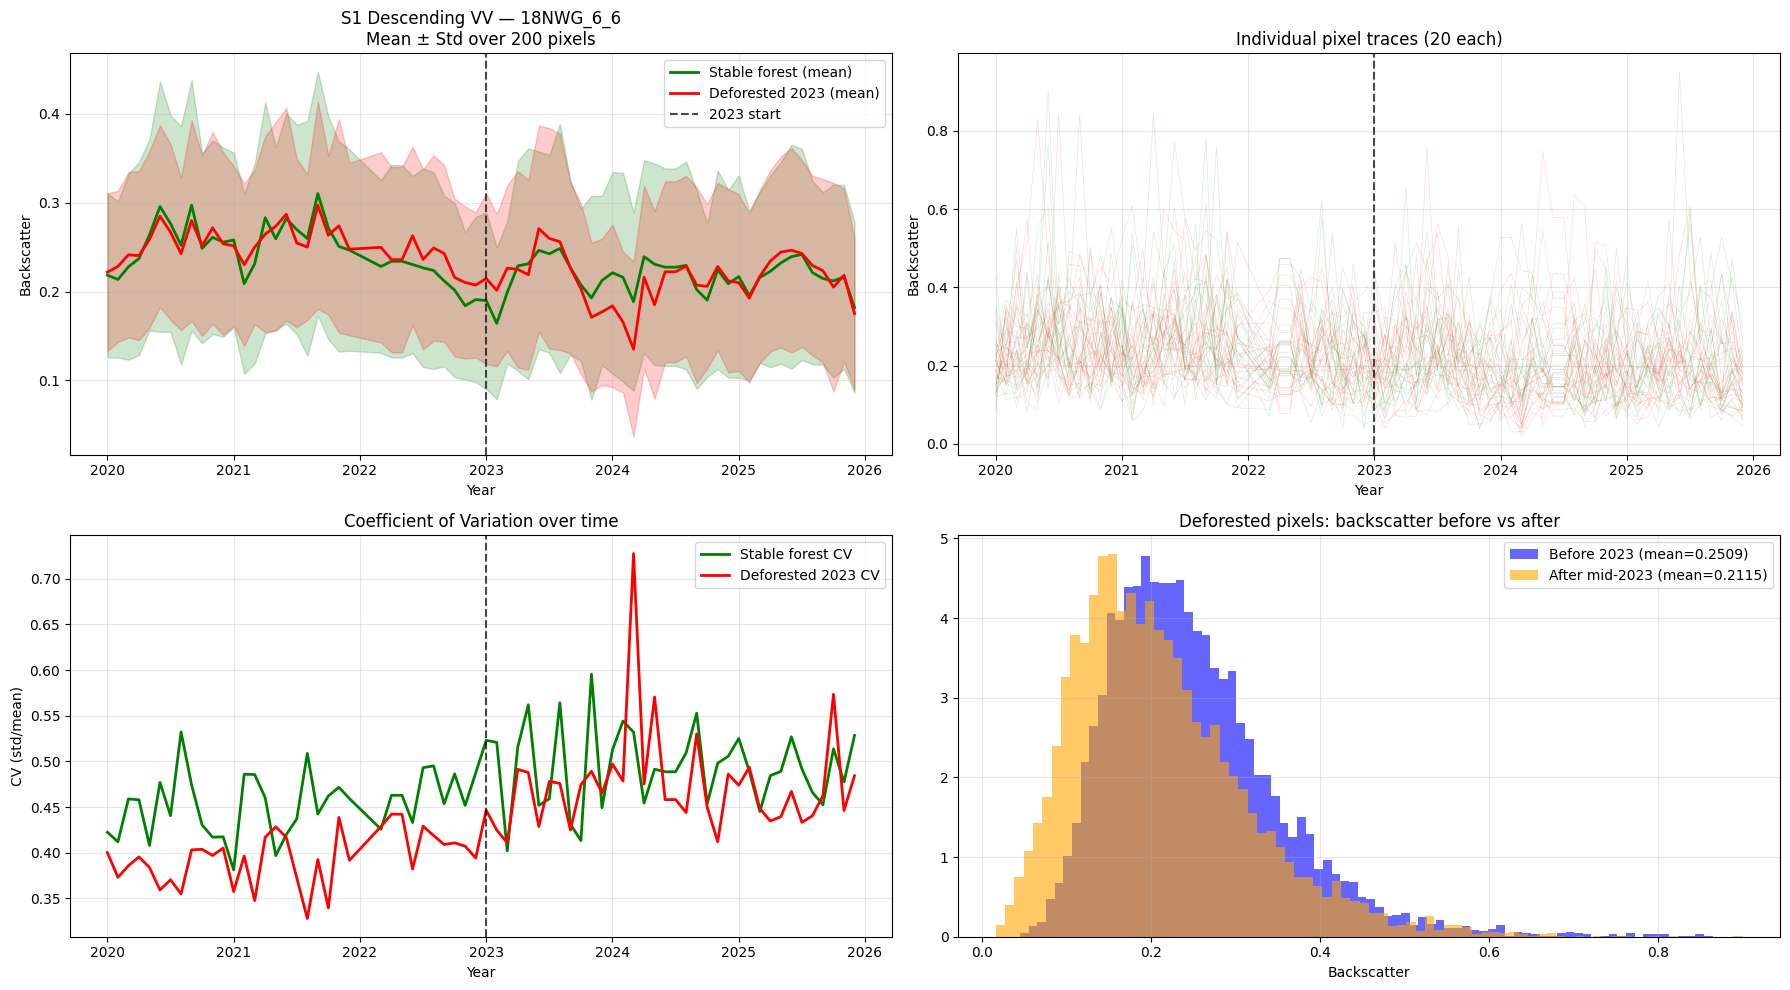


=== Temporal consistency metrics ===
Stable forest:     mean CV = 0.475  (lower = more consistent)
Deforested (2023): mean CV = 0.436

Deforested pixels backscatter:
  Before 2023: mean = 0.2509
  After  2023: mean = 0.2115
  Drop: 15.7%


In [13]:
# --- Plot: mean backscatter over time for deforested vs stable pixels ---
# Replace NaN/0 with NaN for clean stats
defor_clean = np.where((defor_ts == 0) | ~np.isfinite(defor_ts), np.nan, defor_ts)
stable_clean = np.where((stable_ts == 0) | ~np.isfinite(stable_ts), np.nan, stable_ts)

defor_mean = np.nanmean(defor_clean, axis=1)
stable_mean = np.nanmean(stable_clean, axis=1)
defor_std = np.nanstd(defor_clean, axis=1)
stable_std = np.nanstd(stable_clean, axis=1)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 1. Mean time series with std envelope
ax = axes[0, 0]
ax.plot(timestamps, stable_mean, 'g-', linewidth=2, label='Stable forest (mean)')
ax.fill_between(timestamps, stable_mean - stable_std, stable_mean + stable_std, alpha=0.2, color='green')
ax.plot(timestamps, defor_mean, 'r-', linewidth=2, label='Deforested 2023 (mean)')
ax.fill_between(timestamps, defor_mean - defor_std, defor_mean + defor_std, alpha=0.2, color='red')
ax.axvline(2023.0, color='black', linestyle='--', alpha=0.7, label='2023 start')
ax.set_title(f'S1 Descending VV — {tile}\nMean ± Std over {n_sample} pixels')
ax.set_xlabel('Year')
ax.set_ylabel('Backscatter')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Individual pixel traces (subsample 20)
ax = axes[0, 1]
for i in range(min(20, stable_clean.shape[1])):
    ax.plot(timestamps, stable_clean[:, i], 'g-', alpha=0.15, linewidth=0.5)
for i in range(min(20, defor_clean.shape[1])):
    ax.plot(timestamps, defor_clean[:, i], 'r-', alpha=0.15, linewidth=0.5)
ax.axvline(2023.0, color='black', linestyle='--', alpha=0.7)
ax.set_title('Individual pixel traces (20 each)')
ax.set_xlabel('Year')
ax.set_ylabel('Backscatter')
ax.grid(True, alpha=0.3)

# 3. Coefficient of variation over time (temporal stability)
defor_cv = defor_std / (defor_mean + 1e-8)
stable_cv = stable_std / (stable_mean + 1e-8)
ax = axes[1, 0]
ax.plot(timestamps, stable_cv, 'g-', linewidth=2, label='Stable forest CV')
ax.plot(timestamps, defor_cv, 'r-', linewidth=2, label='Deforested 2023 CV')
ax.axvline(2023.0, color='black', linestyle='--', alpha=0.7)
ax.set_title('Coefficient of Variation over time')
ax.set_xlabel('Year')
ax.set_ylabel('CV (std/mean)')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Before vs After 2023: histogram comparison for deforested pixels
before_mask = timestamps < 2023.0
after_mask = timestamps >= 2023.5  # well after deforestation
ax = axes[1, 1]
before_vals = defor_clean[before_mask].flatten()
after_vals = defor_clean[after_mask].flatten()
before_vals = before_vals[np.isfinite(before_vals)]
after_vals = after_vals[np.isfinite(after_vals)]
ax.hist(before_vals, bins=80, alpha=0.6, color='blue', density=True, label=f'Before 2023 (mean={before_vals.mean():.4f})')
ax.hist(after_vals, bins=80, alpha=0.6, color='orange', density=True, label=f'After mid-2023 (mean={after_vals.mean():.4f})')
ax.set_title('Deforested pixels: backscatter before vs after')
ax.set_xlabel('Backscatter')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary stats
print(f'\n=== Temporal consistency metrics ===')
print(f'Stable forest:     mean CV = {np.nanmean(stable_cv):.3f}  (lower = more consistent)')
print(f'Deforested (2023): mean CV = {np.nanmean(defor_cv):.3f}')
print(f'\nDeforested pixels backscatter:')
print(f'  Before 2023: mean = {before_vals.mean():.4f}')
print(f'  After  2023: mean = {after_vals.mean():.4f}')
print(f'  Drop: {(before_vals.mean() - after_vals.mean()) / before_vals.mean() * 100:.1f}%')